In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

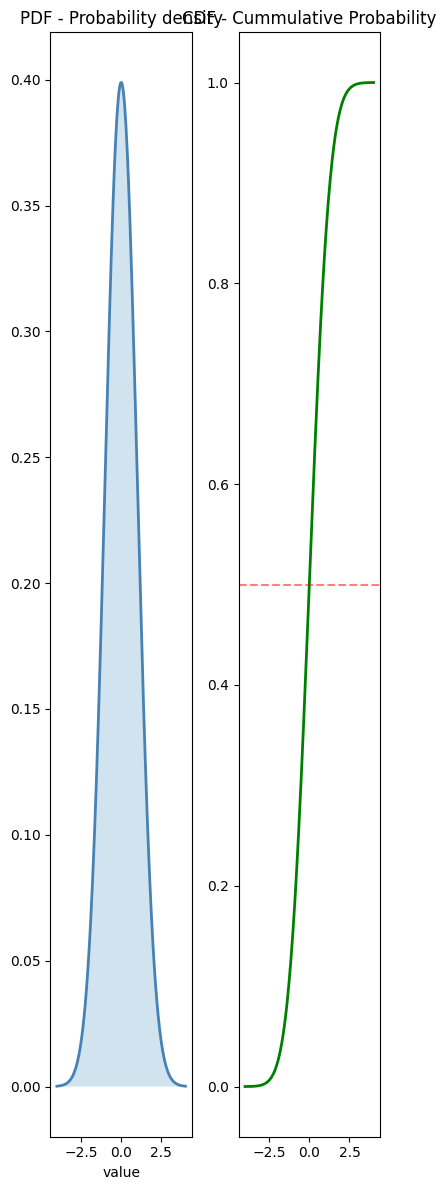

In [5]:

# ── PART 1: Normal distribution ───────────────────────────

mu,sigma = 0,1
x = np.linspace(-4,4,200)

pdf = stats.norm.pdf(x, mu, sigma)

cdf = stats.norm.cdf(x, mu, sigma)

Fig, (ax1, ax2) = plt.subplots(1,2, figsize = (4,12))
ax1.plot(x, pdf, color = 'steelblue', linewidth = 2)
ax1.fill_between(x, pdf, alpha = 0.2)
ax1.set_title('PDF - Probability density')
ax1.set_xlabel('value')

ax2.plot(x, cdf, color = 'green', linewidth = 2)
ax2.axhline(0.5, linestyle = '--', color = 'red', alpha = 0.5)
ax2.set_title('CDF - Cummulative Probability')
plt.tight_layout()
plt.show()

In [ ]:
print(f"P(-1 < X < 1) = {stats.norm.cdf(1) - stats.norm.cdf(-1):.3f}")
print(f"P(-2 < X < 2) = {stats.norm.cdf(2) - stats.norm.cdf(-2):.3f}")
print(f"P(-3 < X < 3) = {stats.norm.cdf(3) - stats.norm.cdf(-3):.3f}")

P(-1 < X < 1) = 0.683
P(-2 < X < 2) = 0.954
P(-3 < X < 3) = 0.997


In [4]:

# ── PART 2: Bernoulli — simulate coin flips ───────────────

p = 0.7        # 70% biased coin
N = 1000

flips = np.random.binomial(1, p, N)

print(f"\nTrue P: {p}")
print(f"Actual P: {flips.mean():.3f}")
print(f"Variance: {flips.var():.3f}")


True P: 0.7
Actual P: 0.726
Variance: 0.199


In [ ]:

# ── PART 3: Bayes theorem ─────────────────────────────────

def bayes_spam(p_spam, p_word_given_spam, p_word_given_ham):
    p_ham = 1 - p_spam
    p_word = (p_spam*p_word_given_spam) + (p_ham*p_word_given_ham)
    posterior = (p_word_given_spam*p_spam) / p_word
    return posterior

result = bayes_spam(
    p_spam = 0.3,
    p_word_given_spam = 0.05,
    p_word_given_ham = 0.4
)

# print(f"\nP(spam | 'free') = {result:.3f}")

print(f"\nP(spam | 'meeting') = {result:.3f}")


P(spam | 'meeting') = 0.051


In [1]:
def naive_bayes_two_words(p_spam, p_w1_spam, p_w2_spam, p_w1_ham, p_w2_ham):
    
    p_both_spam = p_w1_spam * p_w2_spam
    p_both_ham = p_w1_ham * p_w2_ham
    
    p_ham = 1 - p_spam
    p_both = p_both_spam * p_spam + p_both_ham * p_ham
    
    return (p_both_spam * p_spam)/p_both

res = naive_bayes_two_words(
    p_spam = 0.3,
    p_w1_spam=0.8,
    p_w2_spam=0.1,
    p_w1_ham=0.05,
    p_w2_ham=0.4
)

print(f"P(spam | 'free' AND 'meeting'): {res:.3f}")

P(spam | 'free' AND 'meeting'): 0.632
